In [ ]:
# ===== Cell 1: Unzip Train.zip and Test.zip already in /content =====
import os, shutil, zipfile
from pathlib import Path

ROOT = Path("/content")
RAW_DIR = ROOT / "dataset_raw"
TRAIN_ZIP = ROOT / "Train.zip"
TEST_ZIP  = ROOT / "Test.zip"
TRAIN_DST = RAW_DIR / "Train"
TEST_DST  = RAW_DIR / "Test"

# Clean old directories
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)

TRAIN_DST.mkdir(parents=True, exist_ok=True)
TEST_DST.mkdir(parents=True, exist_ok=True)

def unzip_to(zip_path: Path, dst_dir: Path):
    if not zip_path.exists():
        raise FileNotFoundError(f"{zip_path} not found in /content")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dst_dir)

    # Normalize: if zip contains a single top folder, flatten it
    entries = [p for p in dst_dir.iterdir()]
    if len(entries) == 1 and entries[0].is_dir():
        inner = entries[0]
        for p in inner.iterdir():
            shutil.move(str(p), dst_dir / p.name)
        shutil.rmtree(inner)

def report(dir_path: Path, name: str):
    print(f"[{name}] → {dir_path}")
    imgs = list(dir_path.rglob("*.jpg")) + list(dir_path.rglob("*.jpeg")) + list(dir_path.rglob("*.png"))
    jsons = list(dir_path.rglob("*.json"))

    print(f"  Images found: {len(imgs)}")
    print(f"  JSON files found: {len(jsons)}")
    print("  Example images:", [p.as_posix() for p in imgs[:5]])
    print("  Example JSONs :", [p.as_posix() for p in jsons[:5]])

# unzip both datasets
unzip_to(TRAIN_ZIP, TRAIN_DST)
unzip_to(TEST_ZIP,  TEST_DST)

print("✅ Unzip complete!\n")
report(TRAIN_DST, "TRAIN")
report(TEST_DST, "TEST")


BadZipFile: File is not a zip file

In [ ]:
# ===== Cell 2: Convert JSON annotations into PNG masks =====
# Creates /content/dataset with:
#   train/images, train/masks
#   test/images, test/masks
# Mask values: 0=background, 1=fair corrosion, 2=poor corrosion

import os, json, shutil
from pathlib import Path
import numpy as np
import cv2
from tqdm import tqdm

RAW_DIR = Path("/content/dataset_raw")
FINAL_DIR = Path("/content/dataset")

# Clean old output
if FINAL_DIR.exists():
    shutil.rmtree(FINAL_DIR)

# Create final dataset directories
for split in ["train", "test"]:
    (FINAL_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (FINAL_DIR / split / "masks").mkdir(parents=True, exist_ok=True)

# Label mapping based on your dataset
label_map = {
    "2_Fair_Steel_Corrosion": 1,
    "3_Poor_Steel_Corrosion": 2,
}

def process_split(split):

    img_dir = RAW_DIR / split.capitalize() / "images"
    json_dir = RAW_DIR / split.capitalize() / "json"

    print(f"\nProcessing {split.upper()} ...")

    img_files = sorted(list(img_dir.glob("*.jpg")) +
                       list(img_dir.glob("*.jpeg")) +
                       list(img_dir.glob("*.png")))

    for img_path in tqdm(img_files):

        stem = img_path.stem
        json_path = json_dir / f"{stem}.json"

        if not json_path.exists():
            print(f"⚠️ Missing JSON for: {img_path}")
            continue

        # Load image
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]

        # Blank mask
        mask = np.zeros((h, w), dtype=np.uint8)

        # Load JSON annotation
        with open(json_path, "r") as f:
            data = json.load(f)

        shapes = data.get("shapes", [])

        for shape in shapes:
            label = shape["label"]
            points = shape["points"]

            if label not in label_map:
                continue  # skip unknown labels

            class_id = label_map[label]
            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [pts], class_id)

        # Save mask
        out_mask_path = FINAL_DIR / split / "masks" / f"{stem}.png"
        cv2.imwrite(str(out_mask_path), mask)

        # Save (copy) the corresponding image
        out_img_path = FINAL_DIR / split / "images" / f"{stem}.jpg"
        cv2.imwrite(str(out_img_path), img)

# Run for both TRAIN and TEST
process_split("train")
process_split("test")

print("\n🎉 JSON → MASK conversion complete!")
print("Your final dataset is in: /content/dataset")



Processing TRAIN ...


100%|██████████| 396/396 [00:17<00:00, 22.87it/s]



Processing TEST ...


100%|██████████| 44/44 [00:02<00:00, 21.00it/s]


🎉 JSON → MASK conversion complete!
Your final dataset is in: /content/dataset


Found 396 images.
Visualizing: /content/dataset/train/images/363.jpg


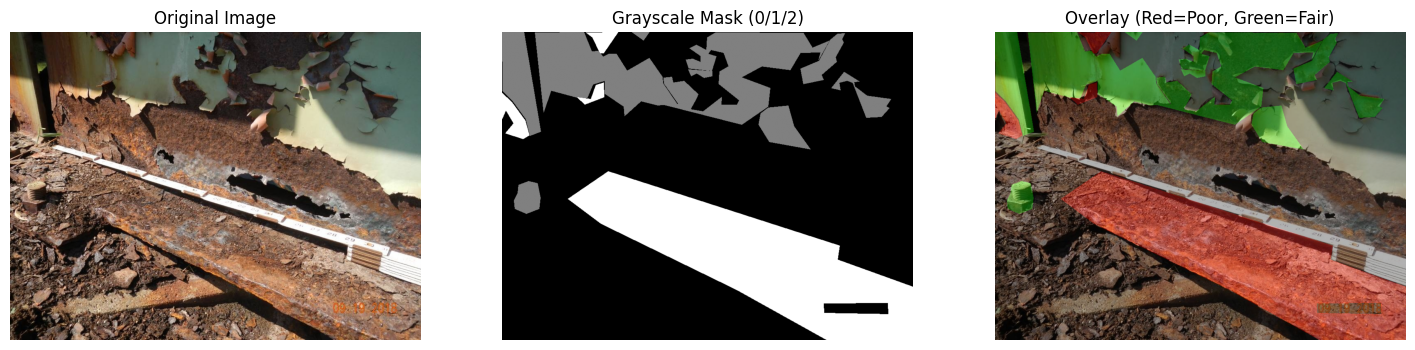

In [ ]:
# ===== Cell 3: Visualize images, masks, and overlays =====

import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

DATASET_DIR = Path("/content/dataset/train")  # you can switch to test if needed

# load all images
image_paths = sorted(list((DATASET_DIR / "images").glob("*.jpg")))
if len(image_paths) == 0:
    print("❌ No images found in /content/dataset/train/images")
else:
    print(f"Found {len(image_paths)} images.")

def visualize_sample(img_path):

    stem = img_path.stem
    mask_path = DATASET_DIR / "masks" / f"{stem}.png"

    # Load image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Create a color mask for visualization
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    # class 1 = fair → GREEN
    color_mask[mask == 1] = (0, 255, 0)

    # class 2 = poor → RED
    color_mask[mask == 2] = (255, 0, 0)

    # overlay
    overlay = cv2.addWeighted(img, 0.7, color_mask, 0.3, 0)

    # plot
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Grayscale Mask (0/1/2)")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Overlay (Red=Poor, Green=Fair)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


# pick one random sample
sample = random.choice(image_paths)
print("Visualizing:", sample)
visualize_sample(sample)


In [ ]:
# ===== Cell 4: Install SegFormer + training dependencies =====

!pip install -q transformers==4.38.2
!pip install -q datasets==2.19.1
!pip install -q accelerate==0.27.2
!pip install -q albumentations==1.4.3
!pip install -q opencv-python==4.9.0.80
!pip install -q timm==0.9.16
!pip install -q scipy
!pip install -q matplotlib

print("🔥 All training dependencies installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 16.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
sentence-transformers 5.1.2 require

In [ ]:
# ===== Cell 5: Build Dataset Class for SegFormer =====

import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
from pathlib import Path
import albumentations as A

class CorrosionDataset(Dataset):
    def __init__(self, root_dir, split="train", image_size=512, augment=True):
        self.root = Path(root_dir) / split
        self.image_paths = sorted(list((self.root / "images").glob("*.jpg")))
        self.mask_paths  = sorted(list((self.root / "masks").glob("*.png")))
        self.image_size = image_size
        self.augment = augment

        # Basic augmentations
        if augment:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.3),
                A.ColorJitter(p=0.4),
                A.GaussianBlur(p=0.2),
                A.RandomBrightnessContrast(p=0.4),
                A.Resize(image_size, image_size),
            ])
        else:
            self.transform = A.Compose([
                A.Resize(image_size, image_size),
            ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Load image + mask
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # Apply augmentation
        transformed = self.transform(image=img, mask=mask)
        img = transformed["image"]
        mask = transformed["mask"]

        # Normalize image → [0,1]
        img = img.astype(np.float32) / 255.0

        # HWC → CHW
        img = np.transpose(img, (2, 0, 1))

        # Convert to torch
        img_tensor = torch.tensor(img, dtype=torch.float32)
        mask_tensor = torch.tensor(mask, dtype=torch.long)  # segmentation expects long

        return img_tensor, mask_tensor

print("🔥 Dataset class created successfully!")


🔥 Dataset class created successfully!


In [ ]:
# ===== Cell 6: Build DataLoaders =====

from torch.utils.data import DataLoader

DATASET_ROOT = "/content/dataset"
IMAGE_SIZE = 512
BATCH_SIZE = 4

# Create dataset objects
train_dataset = CorrosionDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True
)

test_dataset = CorrosionDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("🔥 DataLoaders created successfully!")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")


🔥 DataLoaders created successfully!
Train samples: 396
Test samples:  44


In [ ]:
# ===== Cell 7: Load SegFormer model =====

import torch
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

NUM_CLASSES = 3  # background, fair, poor

# Load processor (normalizes images for SegFormer)
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b1-finetuned-cityscapes-1024-1024"
)

# Load SegFormer model
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b1-finetuned-cityscapes-1024-1024",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True  # needed when resizing classifier head
)

model = model.to("cuda")
print("🔥 SegFormer model loaded and moved to GPU!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/image_processing_segformer.py:102: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.8M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b1-finetuned-cityscapes-1024-1024 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([19, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([19]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔥 SegFormer model loaded and moved to GPU!


In [ ]:
# ===== Cell 8: Full Training Loop for SegFormer =====

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

device = "cuda"

# Loss function for segmentation
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

# Scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10  # You can increase later to 30–50 for better accuracy

def evaluate():
    model.eval()
    total = 0
    correct = 0
    total_loss = 0

    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=imgs).logits
            outputs = torch.nn.functional.interpolate(outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == masks).sum().item()
            total += masks.numel()

    accuracy = correct / total
    avg_loss = total_loss / len(test_loader)
    return avg_loss, accuracy

# ===== Training Loop =====
print("🔥 Starting training...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=imgs).logits
        outputs = torch.nn.functional.interpolate(outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    # Evaluate
    val_loss, val_acc = evaluate()

    print(f"\n📘 Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss / len(train_loader):.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc * 100:.2f}%")
    print("-" * 50)

# Save the model at the end
torch.save(model.state_dict(), "/content/segformer_corrosion.pth")
print("💾 Model saved to /content/segformer_corrosion.pth")


🔥 Starting training...


Epoch 1/10:   0%|          | 0/99 [00:00<?, ?it/s]


📘 Epoch 1/10
Train Loss: 0.9355
Val Loss:   0.8015
Val Acc:    71.48%
--------------------------------------------------


Epoch 2/10:   0%|          | 0/99 [00:00<?, ?it/s]


📘 Epoch 2/10
Train Loss: 0.6938
Val Loss:   0.5591
Val Acc:    81.60%
--------------------------------------------------


...


📘 Epoch 8/10
Train Loss: 0.4041
Val Loss:   0.3500
Val Acc:    87.43%
--------------------------------------------------


Epoch 9/10:   0%|          | 0/99 [00:00<?, ?it/s]


📘 Epoch 9/10
Train Loss: 0.3975
Val Loss:   0.3303
Val Acc:    87.81%
--------------------------------------------------


Epoch 10/10:   0%|          | 0/99 [00:00<?, ?it/s]


📘 Epoch 10/10
Train Loss: 0.3971
Val Loss:   0.3359
Val Acc:    87.71%
--------------------------------------------------
💾 Model saved to /content/segformer_corrosion.pth


In [ ]:
# ===== Cell A: Upload an image from your computer =====
from google.colab import files

uploaded = files.upload()

# This will give you the filename of the uploaded image
for fn in uploaded.keys():
    print("Uploaded:", fn)
    uploaded_image_path = fn  # we will use this in inference


Saving IMG-20251109-WA0023.jpg to IMG-20251109-WA0023.jpg
Uploaded: IMG-20251109-WA0023.jpg


In [ ]:
# ===== Cell B: Inference & Visualization (fixed version) =====

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

# Load trained weights
model.load_state_dict(torch.load("/content/segformer_corrosion.pth", map_location=DEVICE))
model.eval()


def predict_image(img_path, image_size=512):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Preprocess
    resized = cv2.resize(img_rgb, (image_size, image_size))
    norm = resized.astype(np.float32) / 255.0
    chw = np.transpose(norm, (2, 0, 1))
    tensor = torch.tensor(chw, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(pixel_values=tensor).logits
        logits = torch.nn.functional.interpolate(
            logits, size=(h, w), mode="bilinear", align_corners=False
        )
        preds = logits.argmax(dim=1)[0].cpu().numpy()

    # Color mask
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    color_mask[preds == 1] = (0, 255, 0)   # fair
    color_mask[preds == 2] = (255, 0, 0)   # poor

    overlay = cv2.addWeighted(img_rgb, 0.7, color_mask, 0.3, 0)
    return img_rgb, preds, overlay


def show_prediction(img_path):
    img, mask, overlay = predict_image(img_path)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Predicted Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()


print("🔥 Inference ready! Use show_prediction(uploaded_image_path) after uploading an image.")


🔥 Inference ready! Use show_prediction(uploaded_image_path) after uploading an image.


In [ ]:
show_prediction(uploaded_image_path)


NameError: name 'show_prediction' is not defined